<a href="https://colab.research.google.com/github/isuru-madhushan/Phishing-Detection/blob/main/Phishing_Website_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Clean and Preprocess data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import matplotlib
#matplotlib.use('Agg')
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Load the data
df = pd.read_csv('/content/Phishing.csv')

In [3]:
df.head()

,id,NumDots,SubdomainLevel,PathLevel,UrlLength,NumDash,NumDashInHostname,AtSymbol,TildeSymbol,NumUnderscore,...,IframeOrFrame,MissingTitle,ImagesOnlyInForm,SubdomainLevelRT,UrlLengthRT,PctExtResourceUrlsRT,AbnormalExtFormActionR,ExtMetaScriptLinkRT,PctExtNullSelfRedirectHyperlinksRT,CLASS_LABEL
0,1,3,1,5,72,0,0,0,0,0,...,0,0,1,1,0,1,1,-1,1,1
1,2,3,1,3,144,0,0,0,0,2,...,0,0,0,1,-1,1,1,1,1,1
2,3,3,1,2,58,0,0,0,0,0,...,0,0,0,1,0,-1,1,-1,0,1
3,4,3,1,6,79,1,0,0,0,0,...,0,0,0,1,-1,1,1,1,-1,1
4,5,3,0,4,46,0,0,0,0,0,...,1,0,0,1,1,-1,0,-1,-1,1


In [4]:
df.shape

(10000, 50)

In [5]:
#1. Remove unnecessary id column
df = df.drop(columns=['id'])

In [6]:
#2. Handle missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'CLASS_LABEL']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
cleaned_df = df.copy()

print("Missing values per column:")
print(cleaned_df.isnull().sum())

cleaned_df.fillna(0, inplace=True)

print("Missing values per column:")
print(cleaned_df.isnull().sum())

Missing values per column:
NumDots                               0
SubdomainLevel                        0
PathLevel                             0
UrlLength                             0
NumDash                               0
NumDashInHostname                     0
AtSymbol                              0
TildeSymbol                           0
NumUnderscore                         0
NumPercent                            0
NumQueryComponents                    0
NumAmpersand                          0
NumHash                               0
NumNumericChars                       0
NoHttps                               0
RandomString                          0
IpAddress                             0
DomainInSubdomains                    0
DomainInPaths                         0
HttpsInHostname                       0
HostnameLength                        0
PathLength                            0
QueryLength                           0
DoubleSlashInPath                     0
NumSensitiveW

In [7]:
#3. Convert columns to numeric type
cleaned_df[numeric_cols] = cleaned_df[numeric_cols].apply(pd.to_numeric)

In [8]:
#4. Check for duplicates
print(f"Duplicate rows: {cleaned_df.duplicated().sum()}")
cleaned_df.drop_duplicates(inplace=True)
print(f"Duplicate rows: {cleaned_df.duplicated().sum()}")

Duplicate rows: 419
Duplicate rows: 0


In [9]:
cleaned_df.shape

(9581, 49)

###Exploratory Data Analysis

In [10]:
#1. Basic statistics
print("\nBasic statistics:")
print(cleaned_df[numeric_cols].describe())


Basic statistics:
           NumDots  SubdomainLevel    PathLevel    UrlLength      NumDash  \
count  9581.000000     9581.000000  9581.000000  9581.000000  9581.000000   
mean      2.428974        0.570817     3.267509    69.993946     1.844171   
std       1.335516        0.720357     1.852927    33.097013     3.147228   
min       1.000000        0.000000     0.000000    12.000000     0.000000   
25%       2.000000        0.000000     2.000000    48.000000     0.000000   
50%       2.000000        1.000000     3.000000    62.000000     0.000000   
75%       3.000000        1.000000     4.000000    83.000000     2.000000   
max      21.000000       14.000000    18.000000   253.000000    55.000000   

       NumDashInHostname     AtSymbol  TildeSymbol  NumUnderscore  \
count        9581.000000  9581.000000  9581.000000    9581.000000   
mean            0.118568     0.000313     0.012107       0.334829   
std             0.484553     0.017693     0.109371       1.135215   
min        

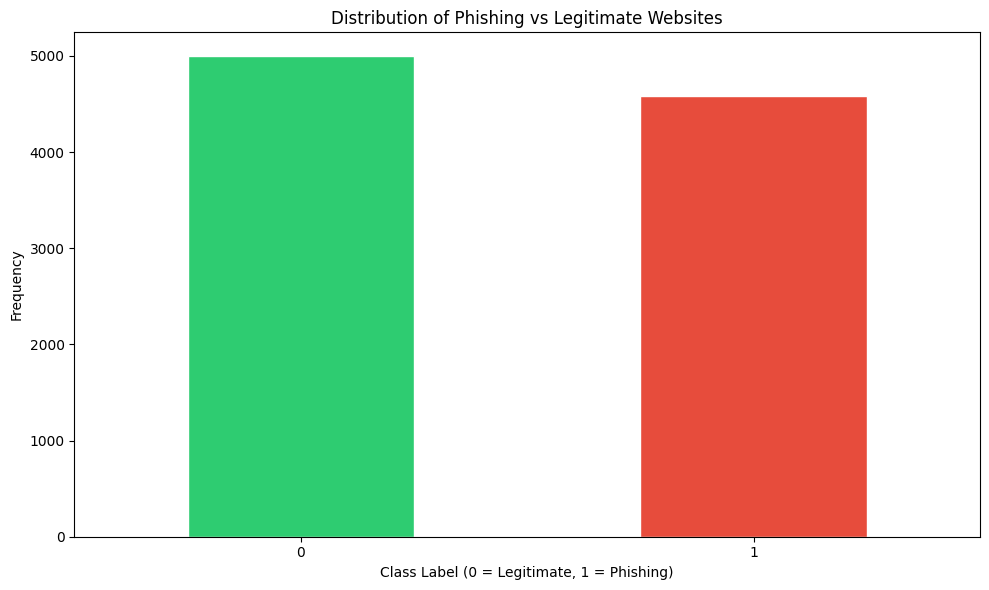

In [21]:
# Class Distribution
fig, ax = plt.subplots(figsize=(10, 6))
class_counts = cleaned_df['CLASS_LABEL'].value_counts()
class_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='white', ax=ax)
ax.set_title("Distribution of Phishing vs Legitimate Websites")
ax.set_xlabel("Class Label (0 = Legitimate, 1 = Phishing)")
ax.set_ylabel("Frequency")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fig_class_dist.png', dpi=120, bbox_inches='tight')
display(fig)
plt.close()

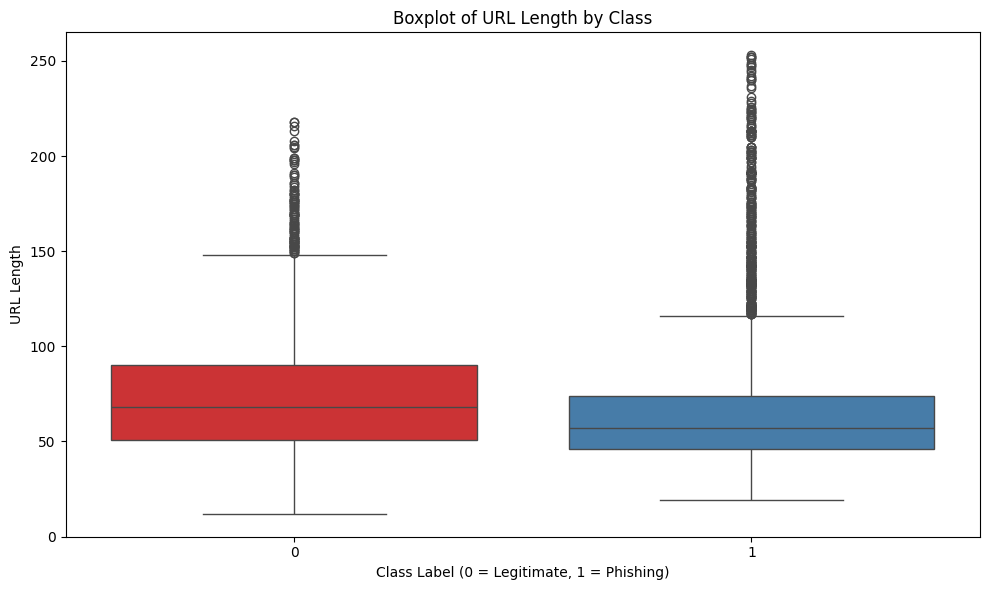

In [22]:
# Boxplot of URL Length
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=cleaned_df, x='CLASS_LABEL', y='UrlLength', palette='Set1', ax=ax)
ax.set_title("Boxplot of URL Length by Class")
ax.set_xlabel("Class Label (0 = Legitimate, 1 = Phishing)")
ax.set_ylabel("URL Length")
plt.tight_layout()
plt.savefig('fig_urllen_boxplot.png', dpi=120, bbox_inches='tight')
display(fig)
plt.close()

In [36]:
# 3. Average Feature Values by Class
avg_by_class = cleaned_df.groupby('CLASS_LABEL')[numeric_cols].mean()
avg_by_class[['UrlLength', 'NumDots', 'SubdomainLevel',
                     'NumDash', 'NumNumericChars', 'NumSensitiveWords']]

,UrlLength,NumDots,SubdomainLevel,NumDash,NumNumericChars,NumSensitiveWords
CLASS_LABEL,,,,,,
0,72.791233,2.049039,0.554043,2.976581,5.630905,0.015212
1,66.945911,2.842966,0.589095,0.610251,5.403490,0.201527


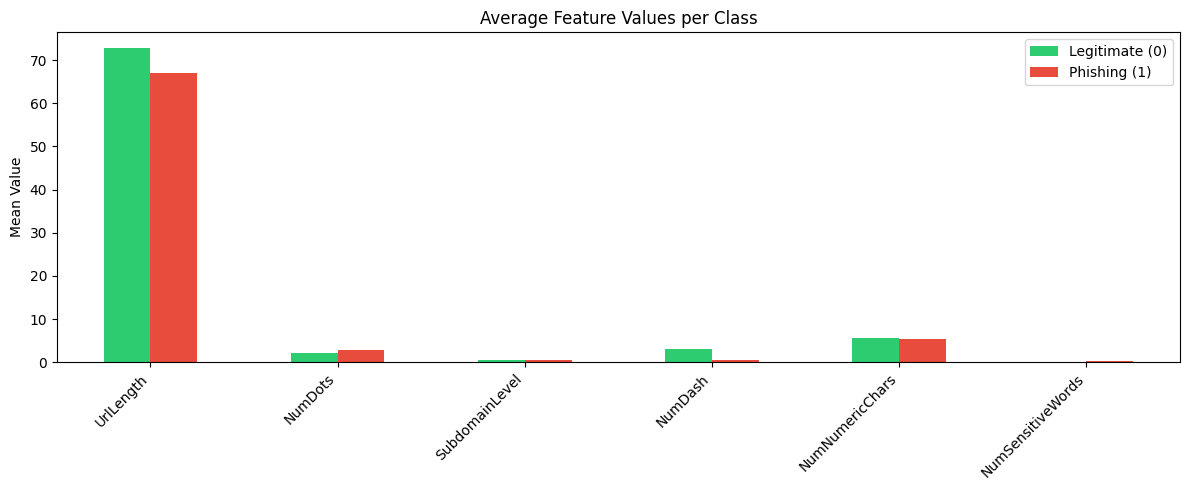

In [35]:
fig, ax = plt.subplots(figsize=(12, 5))
avg_by_class[['UrlLength','NumDots','SubdomainLevel',
              'NumDash','NumNumericChars','NumSensitiveWords']].T.plot(
    kind='bar', color=['#2ecc71','#e74c3c'], ax=ax)
ax.set_title("Average Feature Values per Class")
ax.set_ylabel("Mean Value")
plt.xticks(rotation=45, ha='right')
ax.legend(['Legitimate (0)', 'Phishing (1)'])
plt.tight_layout()
plt.savefig('fig_avg_features.png', dpi=120, bbox_inches='tight')
display(fig)
plt.close()

In [38]:
# 4. Principal Component Analysis (PCA)
scaler = StandardScaler()
nutrition_scaled = scaler.fit_transform(cleaned_df[numeric_cols])

pca = PCA()
principal_components = pca.fit_transform(nutrition_scaled)

eigenvalues = pca.explained_variance_
print("Eigenvalues (Explained Variance):")
print(eigenvalues[:10])
print('\n')

total_variation = sum(eigenvalues)
print(f"Total Variation: {total_variation:.4f}")

Eigenvalues (Explained Variance):
[4.69552535 3.82767191 3.39562377 3.29621325 2.35186579 1.89985679
 1.50642655 1.28367637 1.24729966 1.17818768]


Total Variation: 47.0049


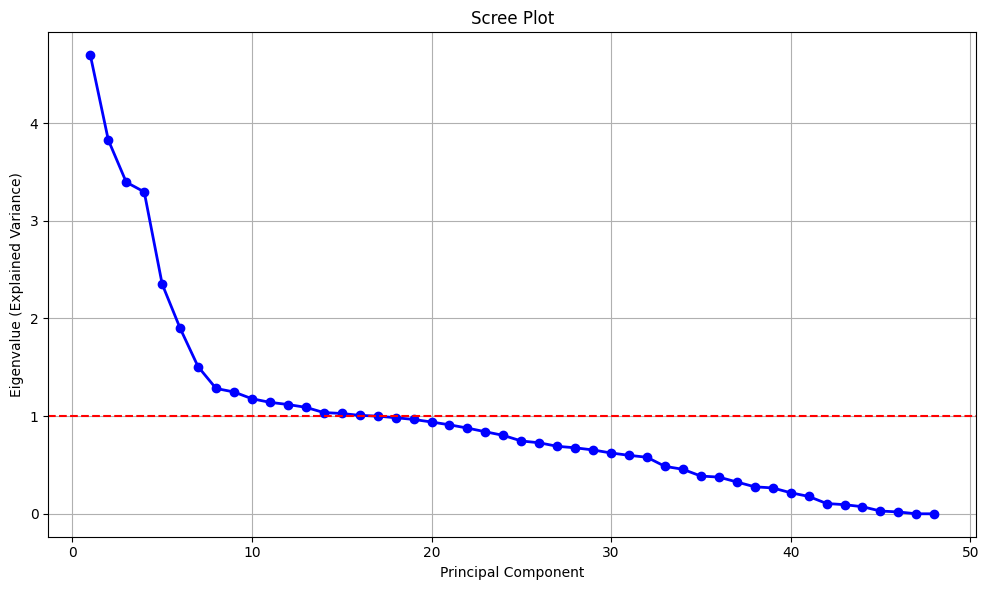

In [39]:
# Scree plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, len(eigenvalues)+1), eigenvalues, 'bo-', linewidth=2)
ax.set_title('Scree Plot')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Eigenvalue (Explained Variance)')
ax.axhline(y=1, color='r', linestyle='--')
ax.grid()
plt.tight_layout()
plt.savefig('fig_scree.png', dpi=120, bbox_inches='tight')
display(fig)
plt.close()

In [40]:
# Calculate proportion of variation for each component
proportions = eigenvalues / total_variation
print("\nProportion of Total Variation for Each Principal Component:")
for i, prop in enumerate(proportions[:10]):
    print(f"PC{i+1}: {prop:.4f} ({prop*100:.2f}%)")


Proportion of Total Variation for Each Principal Component:
PC1: 0.0999 (9.99%)
PC2: 0.0814 (8.14%)
PC3: 0.0722 (7.22%)
PC4: 0.0701 (7.01%)
PC5: 0.0500 (5.00%)
PC6: 0.0404 (4.04%)
PC7: 0.0320 (3.20%)
PC8: 0.0273 (2.73%)
PC9: 0.0265 (2.65%)
PC10: 0.0251 (2.51%)


In [41]:
# Cumulative proportion
cumulative_prop = np.cumsum(proportions)
print("\nCumulative Proportion of Total Variation:")
for i, cum_prop in enumerate(cumulative_prop[:10]):
    print(f"PC1 to PC{i+1}: {cum_prop:.4f} ({cum_prop*100:.2f}%)")


Cumulative Proportion of Total Variation:
PC1 to PC1: 0.0999 (9.99%)
PC1 to PC2: 0.1813 (18.13%)
PC1 to PC3: 0.2536 (25.36%)
PC1 to PC4: 0.3237 (32.37%)
PC1 to PC5: 0.3737 (37.37%)
PC1 to PC6: 0.4141 (41.41%)
PC1 to PC7: 0.4462 (44.62%)
PC1 to PC8: 0.4735 (47.35%)
PC1 to PC9: 0.5000 (50.00%)
PC1 to PC10: 0.5251 (52.51%)


In [42]:
# Eigenvectors (loadings)
eigenvectors = pca.components_
print("\nEigenvectors (Principal Components Loadings):")
for i, component in enumerate(eigenvectors[:5]):
    print(f"\nPrincipal Component {i+1}:")
    print(pd.Series(component, index=numeric_cols))


Eigenvectors (Principal Components Loadings):

Principal Component 1:
NumDots                               0.162443
SubdomainLevel                        0.087342
PathLevel                             0.119653
UrlLength                             0.419691
NumDash                               0.138464
NumDashInHostname                     0.058722
AtSymbol                              0.000524
TildeSymbol                           0.025786
NumUnderscore                         0.182168
NumPercent                            0.095389
NumQueryComponents                    0.292531
NumAmpersand                          0.292251
NumHash                               0.143307
NumNumericChars                       0.313857
NoHttps                               0.014067
RandomString                          0.098730
IpAddress                             0.081556
DomainInSubdomains                    0.088173
DomainInPaths                         0.077496
HttpsInHostname                     

In [43]:
# Class-wise Data Balance
print(cleaned_df["CLASS_LABEL"].value_counts())

CLASS_LABEL
0    4996
1    4585
Name: count, dtype: int64


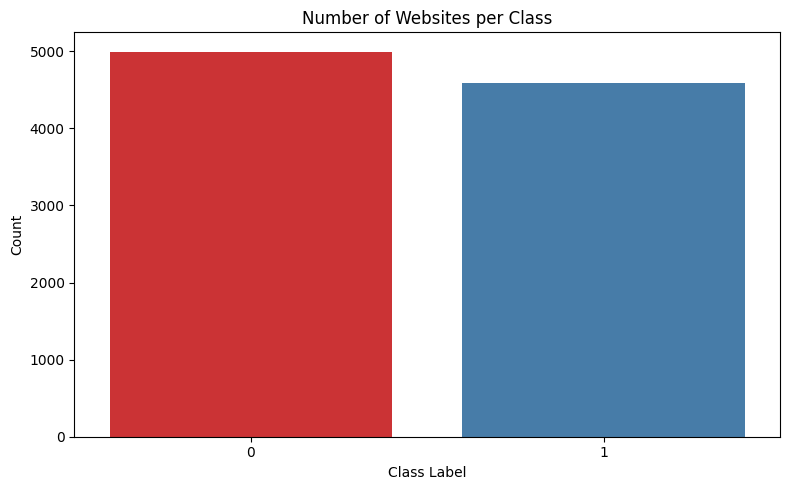

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=cleaned_df, x='CLASS_LABEL',
              hue='CLASS_LABEL', palette='Set1', legend=False,
              order=cleaned_df['CLASS_LABEL'].value_counts().index, ax=ax)
ax.set_xlabel("Class Label")
ax.set_ylabel("Count")
ax.set_title("Number of Websites per Class")
plt.tight_layout()
plt.savefig('fig_class_count.png', dpi=120, bbox_inches='tight')
display(fig)
plt.close()

             UrlLength   NumDots  NumSensitiveWords  PctExtHyperlinks
CLASS_LABEL                                                          
0            72.791233  2.049039           0.015212          0.152235
1            66.945911  2.842966           0.201527          0.331775
	


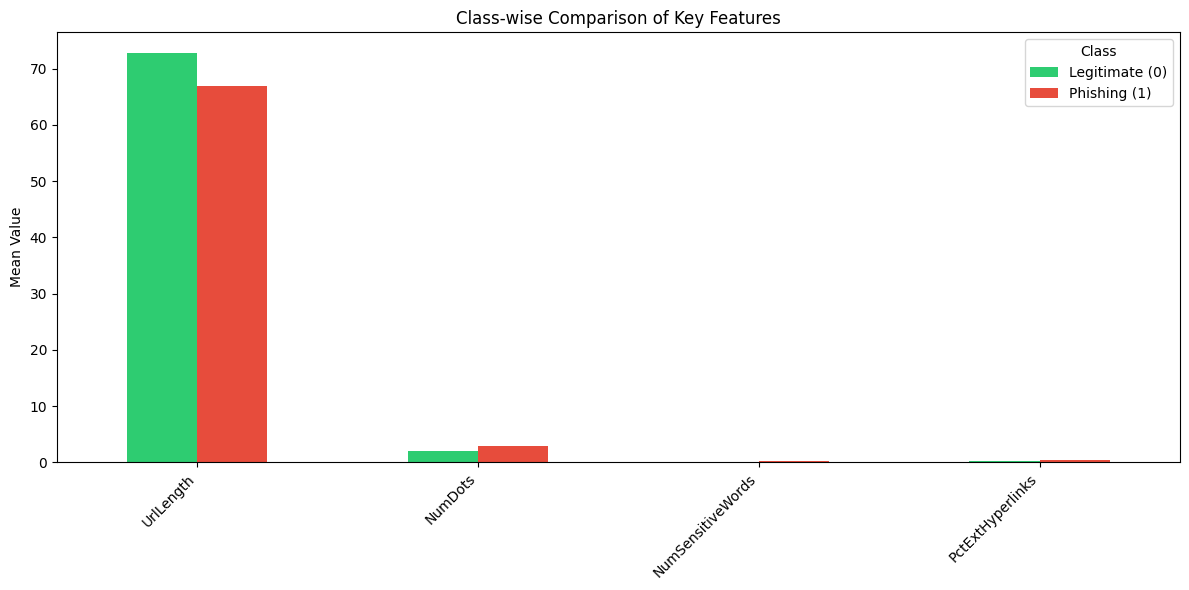

In [58]:
feat_stats = cleaned_df.groupby('CLASS_LABEL')[['UrlLength', 'NumDots', 'NumSensitiveWords', 'PctExtHyperlinks']].mean()
print(feat_stats)
print('\t')
fig, ax = plt.subplots(figsize=(12, 6))
feat_stats.T.plot(kind='bar', stacked=False,
                  color=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Class-wise Comparison of Key Features')
ax.set_ylabel('Mean Value')
plt.xticks(rotation=45, ha='right')
ax.legend(['Legitimate (0)', 'Phishing (1)'], title='Class')
plt.tight_layout()
plt.savefig('fig_classwise_features.png', dpi=120, bbox_inches='tight')
display(fig)
plt.close()

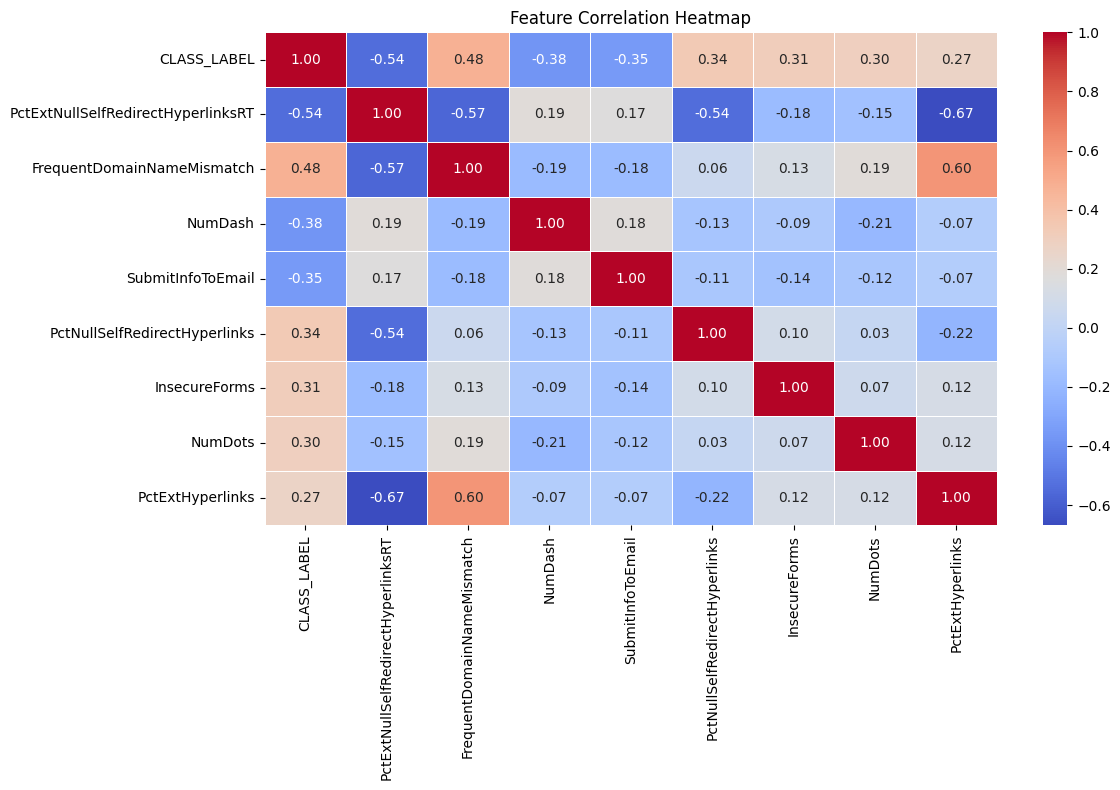

In [46]:
# Correlation heatmap
top_cols = (cleaned_df[numeric_cols + ['CLASS_LABEL']]
            .corr()['CLASS_LABEL'].abs()
            .sort_values(ascending=False)
            .head(9).index.tolist())

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(cleaned_df[top_cols].corr(), annot=True,
            cmap='coolwarm', fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig('fig_heatmap.png', dpi=120, bbox_inches='tight')
display(fig)
plt.close()

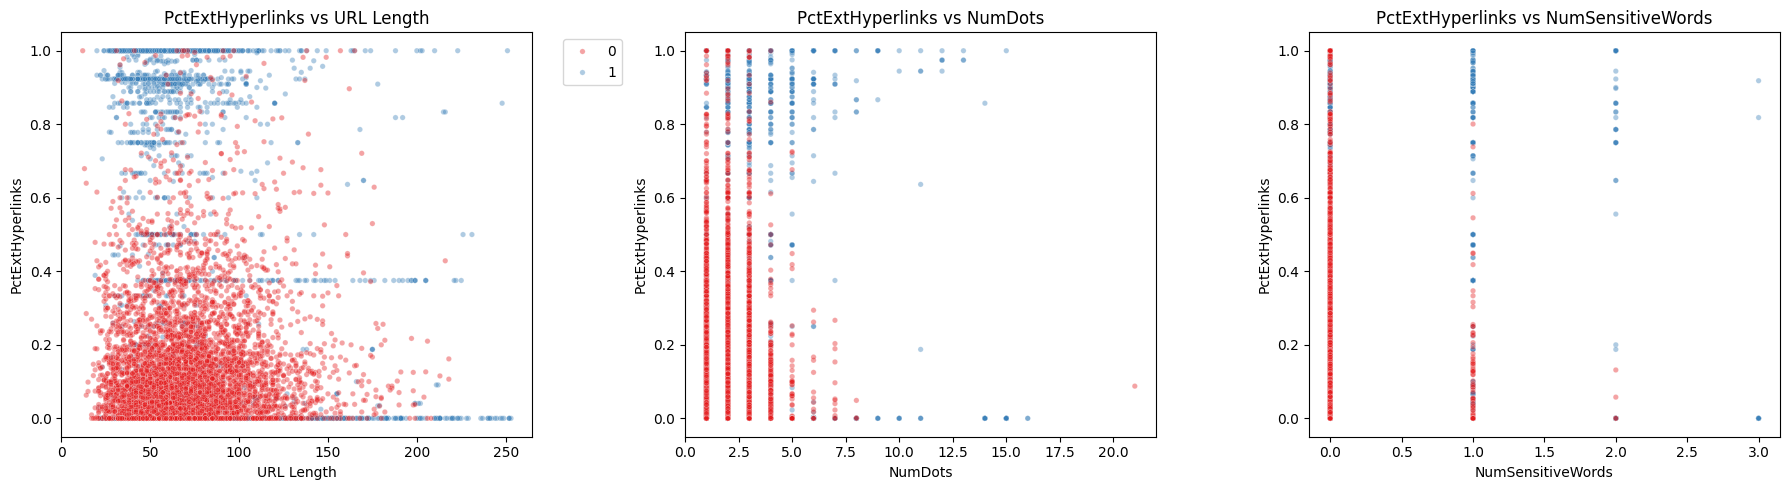

In [47]:
# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x='UrlLength', y='PctExtHyperlinks', data=cleaned_df,
                hue='CLASS_LABEL', palette='Set1', alpha=0.4, s=15, ax=axes[0])
axes[0].set_title('PctExtHyperlinks vs URL Length')
axes[0].set_xlabel('URL Length')
axes[0].set_ylabel('PctExtHyperlinks')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

sns.scatterplot(x='NumDots', y='PctExtHyperlinks', data=cleaned_df,
                hue='CLASS_LABEL', palette='Set1', alpha=0.4, s=15, ax=axes[1])
axes[1].set_title('PctExtHyperlinks vs NumDots')
axes[1].set_xlabel('NumDots')
axes[1].set_ylabel('PctExtHyperlinks')
axes[1].get_legend().remove()

sns.scatterplot(x='NumSensitiveWords', y='PctExtHyperlinks', data=cleaned_df,
                hue='CLASS_LABEL', palette='Set1', alpha=0.4, s=15, ax=axes[2])
axes[2].set_title('PctExtHyperlinks vs NumSensitiveWords')
axes[2].set_xlabel('NumSensitiveWords')
axes[2].set_ylabel('PctExtHyperlinks')
axes[2].get_legend().remove()

plt.tight_layout()
plt.savefig('fig_scatter.png', dpi=120, bbox_inches='tight')
display(fig)
plt.close()

### ML/AI Methods

In [48]:
# Select features and target
X = cleaned_df[numeric_cols]
y = cleaned_df['CLASS_LABEL']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=88, stratify=y)

In [49]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=88)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_prob))
print(classification_report(y_test, lr_pred,
      target_names=['Legitimate', 'Phishing']))


Logistic Regression Performance:
Accuracy: 0.9422608695652174
ROC-AUC: 0.9834414803667562
              precision    recall  f1-score   support

  Legitimate       0.95      0.94      0.94      1499
    Phishing       0.94      0.94      0.94      1376

    accuracy                           0.94      2875
   macro avg       0.94      0.94      0.94      2875
weighted avg       0.94      0.94      0.94      2875



In [50]:
# Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=88)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("\nRandom Forest Performance:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))
print(classification_report(y_test, rf_pred,
      target_names=['Legitimate', 'Phishing']))


Random Forest Performance:
Accuracy: 0.9857391304347826
ROC-AUC: 0.998315252804195
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      1499
    Phishing       0.99      0.98      0.99      1376

    accuracy                           0.99      2875
   macro avg       0.99      0.99      0.99      2875
weighted avg       0.99      0.99      0.99      2875



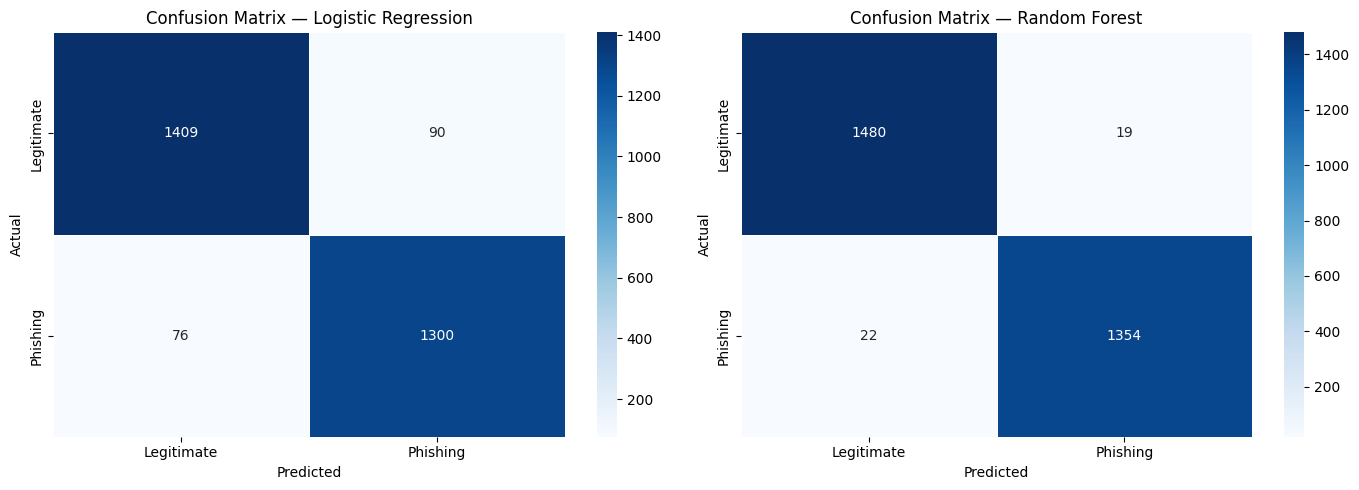

In [51]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pred, title in zip(axes,
                            [lr_pred, rf_pred],
                            ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'],
                linewidths=0.5)
    ax.set_title(f"Confusion Matrix — {title}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig('fig_confusion.png', dpi=120, bbox_inches='tight')
display(fig)
plt.close()

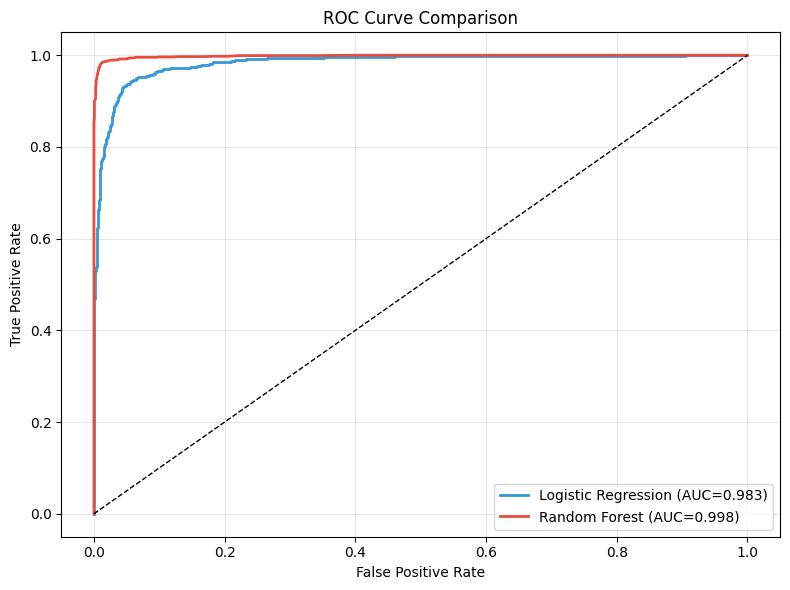

In [52]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
for prob, name, color in [
    (lr_prob, f"Logistic Regression (AUC={roc_auc_score(y_test,lr_prob):.3f})", '#3498db'),
    (rf_prob, f"Random Forest (AUC={roc_auc_score(y_test,rf_prob):.3f})",       '#e74c3c')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, linewidth=2, color=color, label=name)
ax.plot([0,1],[0,1],'k--', linewidth=1)
ax.set_title("ROC Curve Comparison")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_roc.png', dpi=120, bbox_inches='tight')
display(fig)
plt.close()


Top 10 Feature Importances:
PctExtNullSelfRedirectHyperlinksRT    0.183402
PctExtHyperlinks                      0.166527
PctExtResourceUrls                    0.085470
FrequentDomainNameMismatch            0.073512
PctNullSelfRedirectHyperlinks         0.062828
NumDash                               0.052197
ExtMetaScriptLinkRT                   0.040043
NumNumericChars                       0.035842
InsecureForms                         0.027957
SubmitInfoToEmail                     0.027034
dtype: float64


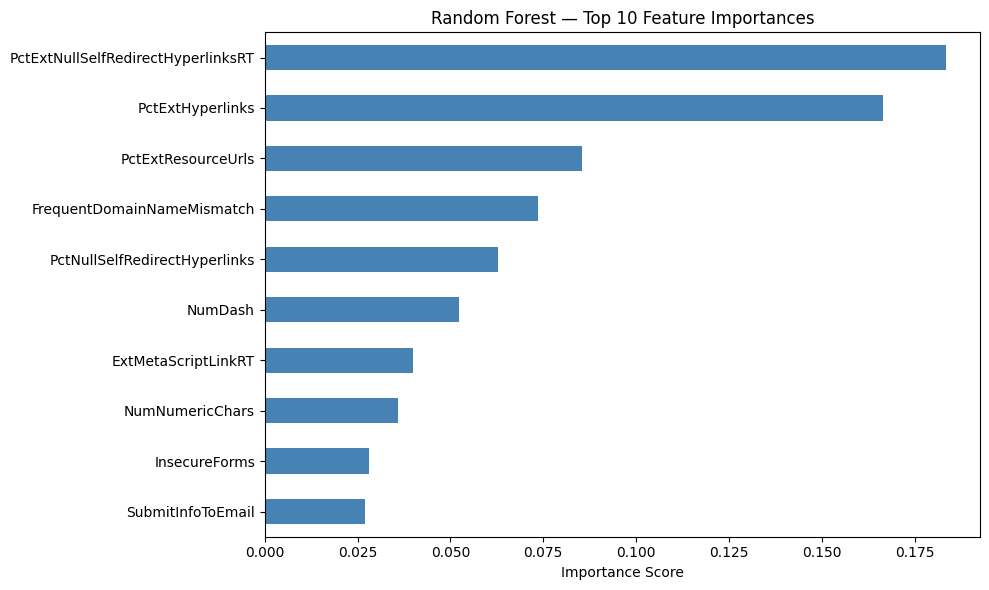

In [53]:
# Feature importances
importances = pd.Series(rf_model.feature_importances_,
                        index=numeric_cols).sort_values(ascending=False).head(10)
print("\nTop 10 Feature Importances:")
print(importances)

fig, ax = plt.subplots(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title("Random Forest — Top 10 Feature Importances")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig('fig_importance.png', dpi=120, bbox_inches='tight')
display(fig)
plt.close()

In [54]:
print("\n=== MODEL SUMMARY ===")
print(f"Logistic Regression : Accuracy={accuracy_score(y_test,lr_pred):.4f}, AUC={roc_auc_score(y_test,lr_prob):.4f}")
print(f"Random Forest       : Accuracy={accuracy_score(y_test,rf_pred):.4f}, AUC={roc_auc_score(y_test,rf_prob):.4f}")
print("\nAll figures saved!")



=== MODEL SUMMARY ===
Logistic Regression : Accuracy=0.9423, AUC=0.9834
Random Forest       : Accuracy=0.9857, AUC=0.9983

All figures saved!
